In [1]:
# Ulises Israel Alarcón Estay - 21.543.468-0 - 27/may/2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [3]:
df = pd.read_csv("dataset_produccion_s13.csv")

In [4]:
df.head()

,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
0,L001,Abrazadera D,Tarde,114,1.95,204.4,37.8,8.0,222.30
1,L002,Válvula E,Tarde,306,2.83,230.8,56.8,11.0,865.98
2,L003,Tuerca C,Tarde,180,3.66,242.8,44.8,4.0,658.80
3,L004,Válvula E,Tarde,210,2.14,242.1,38.5,0.0,449.40
4,L005,Válvula E,Tarde,336,4.87,234.6,14.9,9.0,1636.32


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_lote              60 non-null     str    
 1   producto             60 non-null     str    
 2   turno                60 non-null     str    
 3   unidades_producidas  60 non-null     int64  
 4   costo_unitario       59 non-null     float64
 5   temperatura_horno    59 non-null     float64
 6   tiempo_ciclo_min     60 non-null     float64
 7   defectos             59 non-null     float64
 8   costo_total          60 non-null     float64
dtypes: float64(5), int64(1), str(3)
memory usage: 4.3 KB


In [6]:
df.describe()

,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
count,60.000000,59.000000,59.000000,60.000000,59.000000,60.000000
mean,244.266667,2.664576,229.406780,35.813333,7.203390,656.710667
std,90.248408,1.297236,104.204605,15.335662,4.494363,407.032651
min,84.000000,0.570000,180.400000,-5.000000,0.000000,62.980000
25%,172.500000,1.590000,197.850000,24.600000,4.000000,338.775000
50%,250.500000,2.740000,219.800000,37.450000,7.000000,609.940000
75%,312.250000,3.580000,235.100000,48.825000,11.500000,894.045000
max,397.000000,4.940000,999.900000,59.500000,14.000000,1636.320000


In [7]:
df.isnull().sum()

id_lote                0
producto               0
turno                  0
unidades_producidas    0
costo_unitario         1
temperatura_horno      1
tiempo_ciclo_min       0
defectos               1
costo_total            0
dtype: int64

In [8]:
Q1 = df["temperatura_horno"].quantile(0.25)
Q3 = df["temperatura_horno"].quantile(0.75)

IQR = Q3 - Q1

In [9]:
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

In [10]:
outliers_temp = df[
    (df["temperatura_horno"] < lim_inf) |
    (df["temperatura_horno"] > lim_sup)
]

print(f"Outliers detectados: {len(outliers_temp)}")
print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")

outliers_temp

Outliers detectados: 1
Límite inferior: 141.97
Límite superior: 290.98


,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
33,L034,Tornillo A,Noche,124,0.68,999.9,24.3,4.0,84.32


In [11]:
Q1 = df["tiempo_ciclo_min"].quantile(0.25)
Q3 = df["tiempo_ciclo_min"].quantile(0.75)

IQR = Q3 - Q1

In [12]:
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

In [13]:
outliers_tiempo = df[
    (df["tiempo_ciclo_min"] < lim_inf) |
    (df["tiempo_ciclo_min"] > lim_sup)
]

print(f"Outliers detectados: {len(outliers_tiempo)}")
print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")

outliers_tiempo

Outliers detectados: 0
Límite inferior: -11.74
Límite superior: 85.16


,id_lote,producto,turno,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total


In [14]:
df.shape

(60, 9)

In [15]:
df1 = df.copy()

In [16]:
df1 = df1.dropna()

In [17]:
print("Original:", df.shape)
print("Sin nulos:", df1.shape)

Original: (60, 9)
Sin nulos: (57, 9)


In [18]:
"""
un valor negativo en `tiempo_ciclo_min` no tiene mucho sentido,
porque el tiempo que dura un proceso no puede ser menor a 0.
"""

'\nun valor negativo en `tiempo_ciclo_min` no tiene mucho sentido,\nporque el tiempo que dura un proceso no puede ser menor a 0.\n'

In [19]:
temp = df1["temperatura_horno"]

In [20]:
media = temp.mean()
mediana = temp.median()
desv_std = temp.std()
minimo = temp.min()
maximo = temp.max()

In [21]:
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {desv_std:.2f}")
print(f"Mínimo: {minimo:.2f}")
print(f"Máximo: {maximo:.2f}")

Media: 229.17
Mediana: 218.40
Desviación estándar: 106.03
Mínimo: 180.40
Máximo: 999.90


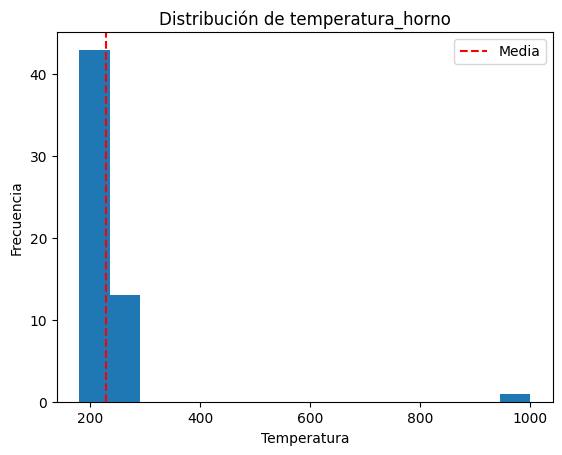

In [22]:
plt.hist(temp, bins=15)

plt.axvline(media, linestyle='--', label='Media', color='red')

plt.title("Distribución de temperatura_horno")
plt.xlabel("Temperatura")
plt.ylabel("Frecuencia")

plt.legend()

plt.show()

In [23]:
"""
la distribucion de `temperatura_horno` no es uniforme,
porque la mayoria de valores se concentra en un rango mas chico,
cerca de los 200-300 grados.

ademas, se ve un valor exageradamente alto cercano a 1000,
que claramente es un outlier y hace que la distribucion quede
bien asimetrica.
"""

'\nla distribucion de `temperatura_horno` no es uniforme,\nporque la mayoria de valores se concentra en un rango mas chico,\ncerca de los 200-300 grados.\n\nademas, se ve un valor exageradamente alto cercano a 1000,\nque claramente es un outlier y hace que la distribucion quede\nbien asimetrica.\n'

In [24]:
def costo_produccion(temperatura):
    T_optima = 220
    costo_base = 1500

    return 0.05 * (temperatura - T_optima)**2 + costo_base

In [25]:
costo_produccion(220)

1500.0

In [26]:
temperaturas = np.linspace(170, 270, 100)

In [27]:
costos = costo_produccion(temperaturas)

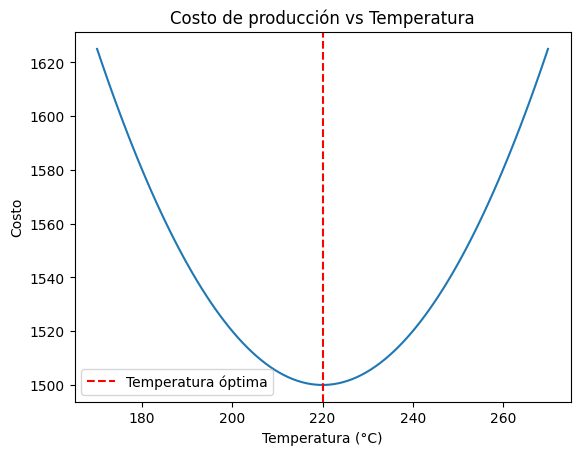

In [28]:
plt.plot(temperaturas, costos)

plt.axvline(220, color='red', linestyle='--', label='Temperatura óptima')

plt.title("Costo de producción vs Temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Costo")

plt.legend()

plt.show()

In [29]:
"""
la funcion tiene forma parabolica y tiene un unico minimo global
en los 220 °C.

por eso se puede decir que es unimodal,
porque solo tiene un minimo dentro del intervalo analizado.

si tiene sentido usar `minimize_scalar` directamente,
porque este metodo funciona bastante bien con funciones unimodales
y encuentra el valor minimo de forma eficiente.
"""

'\nla funcion tiene forma parabolica y tiene un unico minimo global\nen los 220 °C.\n\npor eso se puede decir que es unimodal,\nporque solo tiene un minimo dentro del intervalo analizado.\n\nsi tiene sentido usar `minimize_scalar` directamente,\nporque este metodo funciona bastante bien con funciones unimodales\ny encuentra el valor minimo de forma eficiente.\n'

In [30]:
"""
Una función unimodal es aquella que posee un único extremo local (un solo pico o valle) en su dominio. 
Es decir, la función crece hasta alcanzar un valor máximo (o decrece hasta un mínimo) y 
luego desciende (o asciende) de forma continua,
sin volver a presentar otros extremos.
"""

'\nUna función unimodal es aquella que posee un único extremo local (un solo pico o valle) en su dominio. \nEs decir, la función crece hasta alcanzar un valor máximo (o decrece hasta un mínimo) y \nluego desciende (o asciende) de forma continua,\nsin volver a presentar otros extremos.\n'

In [31]:
"""
La función minimize_scalar de la librería SciPy en Python se utiliza para encontrar el valor mínimo de una 
función matemática que depende de una sola variable (escalar). Es una herramienta fundamental en matemáticas, 
ingeniería y ciencia de datos para optimización unidimensional.
"""

'\nLa función minimize_scalar de la librería SciPy en Python se utiliza para encontrar el valor mínimo de una \nfunción matemática que depende de una sola variable (escalar). Es una herramienta fundamental en matemáticas, \ningeniería y ciencia de datos para optimización unidimensional.\n'

In [32]:
resultado_brent = minimize_scalar(
    costo_produccion,
    method='brent'
)

In [33]:
print("Temperatura óptima:", resultado_brent.x)
print("Costo mínimo:", resultado_brent.fun)
print("Optimización exitosa:", resultado_brent.success)
print("Número de iteraciones:", resultado_brent.nit)

Temperatura óptima: 220.0000000000022
Costo mínimo: 1500.0
Optimización exitosa: True
Número de iteraciones: 4


In [34]:
if resultado_brent.success:
    print("La optimización fue exitosa.")
    print(f"Temperatura óptima encontrada: {resultado_brent.x:.2f} °C")
else:
    print("La optimización falló.")

La optimización fue exitosa.
Temperatura óptima encontrada: 220.00 °C


In [35]:
"""
la temperatura optima encontrada por `minimize_scalar`
coincide con el valor de `T_optima = 220 °C`
que esta definido en la funcion de costo.

esto pasa porque la funcion es una parabola
con un unico minimo global justo en los 220 °C.

el metodo de brent funciona super bien para encontrar minimos
en funciones unimodales, asi que converge correctamente
hacia ese valor.
"""

'\nla temperatura optima encontrada por `minimize_scalar`\ncoincide con el valor de `T_optima = 220 °C`\nque esta definido en la funcion de costo.\n\nesto pasa porque la funcion es una parabola\ncon un unico minimo global justo en los 220 °C.\n\nel metodo de brent funciona super bien para encontrar minimos\nen funciones unimodales, asi que converge correctamente\nhacia ese valor.\n'

In [36]:
resultado_bounded = minimize_scalar(
    costo_produccion,
    bounds=(180, 250),
    method='bounded'
)

In [37]:
print("Temperatura óptima:", resultado_bounded.x)
print("Costo mínimo:", resultado_bounded.fun)
print("Optimización exitosa:", resultado_bounded.success)
print("Número de iteraciones:", resultado_bounded.nit)

Temperatura óptima: 220.00000000000006
Costo mínimo: 1500.0
Optimización exitosa: True
Número de iteraciones: 6


In [38]:
print("Brent:", resultado_brent.x)
print("Bounded:", resultado_bounded.x)

Brent: 220.0000000000022
Bounded: 220.00000000000006


In [39]:
"""
los valores de `resultado_brent.x` y `resultado_bounded.x`
son practicamente iguales,
porque los dos metodos encuentran el minimo global
cerca de los 220 °C.

igual, el metodo `bounded` seria mejor en un contexto industrial real,
porque toma en cuenta las restricciones fisicas
y de seguridad del sistema.
"""

'\nlos valores de `resultado_brent.x` y `resultado_bounded.x`\nson practicamente iguales,\nporque los dos metodos encuentran el minimo global\ncerca de los 220 °C.\n\nigual, el metodo `bounded` seria mejor en un contexto industrial real,\nporque toma en cuenta las restricciones fisicas\ny de seguridad del sistema.\n'

In [40]:
print("Iteraciones Brent:", resultado_brent.nit)
print("Iteraciones Bounded:", resultado_bounded.nit)

Iteraciones Brent: 4
Iteraciones Bounded: 6


In [41]:
"""
el numero de iteraciones puede cambiar entre ambos metodos
por la forma en que hacen la busqueda.

generalmente, `bounded` puede necesitar mas iteraciones
porque limita la busqueda a un intervalo especifico,
mientras que `brent` tiene mas libertad para acercarse
al minimo global.
"""

'\nel numero de iteraciones puede cambiar entre ambos metodos\npor la forma en que hacen la busqueda.\n\ngeneralmente, `bounded` puede necesitar mas iteraciones\nporque limita la busqueda a un intervalo especifico,\nmientras que `brent` tiene mas libertad para acercarse\nal minimo global.\n'

In [42]:
comparacion = pd.DataFrame({
    'Metodo': ['brent', 'bounded'],
    'x_optimo': [resultado_brent.x, resultado_bounded.x],
    'costo_min': [resultado_brent.fun, resultado_bounded.fun],
    'iteraciones': [resultado_brent.nit, resultado_bounded.nit],
    'convergio': [resultado_brent.success, resultado_bounded.success]
})

print(comparacion.to_string(index=False))

 Metodo  x_optimo  costo_min  iteraciones  convergio
  brent     220.0     1500.0            4       True
bounded     220.0     1500.0            6       True


In [43]:
temperaturas = np.linspace(170, 270, 200)
costos = costo_produccion(temperaturas)

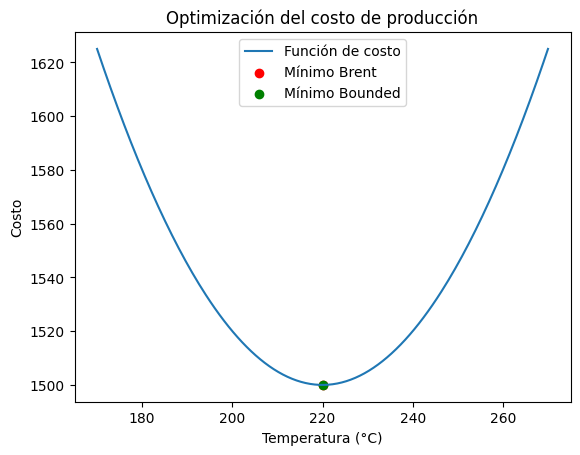

In [44]:

plt.plot(temperaturas, costos, label='Función de costo')

plt.scatter(
    resultado_brent.x,
    resultado_brent.fun,
    color='red',
    label='Mínimo Brent'
)

plt.scatter(
    resultado_bounded.x,
    resultado_bounded.fun,
    color='green',
    label='Mínimo Bounded'
)

plt.title("Optimización del costo de producción")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Costo")

plt.legend()

plt.show()

In [45]:
"""
el argumento `bounds` sirve para limitar la busqueda
a un rango que sea seguro y realista.

en un entorno industrial esto es importante,
porque evita que el algoritmo proponga temperaturas peligrosas
o imposibles de usar en la planta.

ademas, hace que la optimizacion sea mas confiable,
porque incorpora conocimiento del dominio directamente en el modelo.
"""

'\nel argumento `bounds` sirve para limitar la busqueda\na un rango que sea seguro y realista.\n\nen un entorno industrial esto es importante,\nporque evita que el algoritmo proponga temperaturas peligrosas\no imposibles de usar en la planta.\n\nademas, hace que la optimizacion sea mas confiable,\nporque incorpora conocimiento del dominio directamente en el modelo.\n'

In [46]:
"""
si la funcion de costo tuviera varios minimos locales,
`minimize_scalar` podria no ser suficiente
para encontrar el minimo global.

el algoritmo podria converger a un minimo local
dependiendo del intervalo de busqueda
o de como se comporte la funcion.

en ese caso se podrian usar metodos mas avanzados
de optimizacion global,
como algoritmos geneticos, simulated annealing
o differential evolution.
"""

'\nsi la funcion de costo tuviera varios minimos locales,\n`minimize_scalar` podria no ser suficiente\npara encontrar el minimo global.\n\nel algoritmo podria converger a un minimo local\ndependiendo del intervalo de busqueda\no de como se comporte la funcion.\n\nen ese caso se podrian usar metodos mas avanzados\nde optimizacion global,\ncomo algoritmos geneticos, simulated annealing\no differential evolution.\n'

In [47]:
"""
Si el efecto de la temperatura fuera asimétrico,
la función de costo dejaría de ser una parábola simétrica.

Por ejemplo, temperaturas demasiado altas podrían generar costos mucho mayores
que temperaturas bajas debido al desgaste del horno o daños en producción.

En ese caso podría agregarse un término cúbico o exponencial para representar
el comportamiento asimétrico del sistema.
"""

'\nSi el efecto de la temperatura fuera asimétrico,\nla función de costo dejaría de ser una parábola simétrica.\n\nPor ejemplo, temperaturas demasiado altas podrían generar costos mucho mayores\nque temperaturas bajas debido al desgaste del horno o daños en producción.\n\nEn ese caso podría agregarse un término cúbico o exponencial para representar\nel comportamiento asimétrico del sistema.\n'

In [48]:
"""
si el efecto de la temperatura fuera asimetrico,
la funcion de costo dejaria de ser una parabola simetrica.

por ejemplo, temperaturas demasiado altas
podrian generar costos mucho mayores
que temperaturas bajas,
por el desgaste del horno o daños en produccion.

en ese caso se podria agregar un termino cubico
o exponencial para representar mejor
el comportamiento asimetrico del sistema.
"""

'\nsi el efecto de la temperatura fuera asimetrico,\nla funcion de costo dejaria de ser una parabola simetrica.\n\npor ejemplo, temperaturas demasiado altas\npodrian generar costos mucho mayores\nque temperaturas bajas,\npor el desgaste del horno o daños en produccion.\n\nen ese caso se podria agregar un termino cubico\no exponencial para representar mejor\nel comportamiento asimetrico del sistema.\n'